## E-COMMERCE SALES DATA ANALYSIS PROJECT
-  Perform **sales trend analysis** over time
-  Identify **top-selling products** and categories
-  **Segment customers by age, gender, and location**
-  Analyze **city-wise sales performance**
-  Explore **payment method preferences**


In [13]:
# import libs

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# step1: Load Dataset

df = pd.read_csv('./ecommerce_sales_data.csv')
df.head()

,Order ID,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating
0,ORD0001,CUST9376,Female,43,Home,Lamp,1,1368.69,07-06-2025,Cash on Delivery,Hyderabad,3
1,ORD0002,CUST3289,Male,57,Toys,Lego Set,5,782.44,11-12-2024,Cash on Delivery,Chennai,5
2,ORD0003,CUST6409,Female,53,Clothing,Jacket,1,3676.18,05-05-2025,Credit Card,Bangalore,4
3,ORD0004,CUST8815,Female,51,Beauty,Perfume,2,4836.37,25-06-2025,Cash on Delivery,Mumbai,5
4,ORD0005,CUST1018,Female,39,Electronics,Smartphone,4,3580.24,25-12-2024,UPI,Kolkata,3


In [44]:
df.columns

Index(['Order ID', 'Customer ID', 'Gender', 'Age', 'Product Category',
       'Product Name', 'Quantity', 'Price', 'Order Date', 'Payment Method',
       'City', 'Rating'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          100 non-null    str    
 1   Customer ID       100 non-null    str    
 2   Gender            100 non-null    str    
 3   Age               100 non-null    int64  
 4   Product Category  100 non-null    str    
 5   Product Name      100 non-null    str    
 6   Quantity          100 non-null    int64  
 7   Price             100 non-null    float64
 8   Order Date        100 non-null    str    
 9   Payment Method    100 non-null    str    
 10  City              100 non-null    str    
 11  Rating            100 non-null    int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 9.5 KB


In [43]:
df.describe

<bound method NDFrame.describe of    Order ID Customer ID  Gender  Age Product Category Product Name  Quantity  \
0   ORD0001    CUST9376  Female   43             Home         Lamp         1   
1   ORD0002    CUST3289    Male   57             Toys     Lego Set         5   
2   ORD0003    CUST6409  Female   53         Clothing       Jacket         1   
3   ORD0004    CUST8815  Female   51           Beauty      Perfume         2   
4   ORD0005    CUST1018  Female   39      Electronics   Smartphone         4   
..      ...         ...     ...  ...              ...          ...       ...   
95  ORD0096    CUST3955    Male   49             Home     Curtains         4   
96  ORD0097    CUST5677    Male   36           Beauty   Face Cream         4   
97  ORD0098    CUST1271    Male   57             Home     Curtains         3   
98  ORD0099    CUST1105  Female   21         Clothing        Jeans         3   
99  ORD0100    CUST9956  Female   32      Electronics   Headphones         2   

     

In [47]:
# step2: DATA PREPROCESSING

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)
# Convert date column to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])


In [48]:
# Create Sales Column if not  present
df['Sales'] = df['Quantity'] * df['Price']

print(df.head())

  Order ID Customer ID  Gender  Age Product Category Product Name  Quantity  \
0  ORD0001    CUST9376  Female   43             Home         Lamp         1   
1  ORD0002    CUST3289    Male   57             Toys     Lego Set         5   
2  ORD0003    CUST6409  Female   53         Clothing       Jacket         1   
3  ORD0004    CUST8815  Female   51           Beauty      Perfume         2   
4  ORD0005    CUST1018  Female   39      Electronics   Smartphone         4   

     Price Order Date    Payment Method       City  Rating     Sales  
0  1368.69 2025-06-07  Cash on Delivery  Hyderabad       3   1368.69  
1   782.44 2024-12-11  Cash on Delivery    Chennai       5   3912.20  
2  3676.18 2025-05-05       Credit Card  Bangalore       4   3676.18  
3  4836.37 2025-06-25  Cash on Delivery     Mumbai       5   9672.74  
4  3580.24 2024-12-25               UPI    Kolkata       3  14320.96  


Monthly Sales Trend
Order Date
2024-07    17411.29
2024-08    94121.76
2024-09    90122.59
2024-10    26986.55
2024-11    58692.98
2024-12    44666.03
2025-01    51865.59
2025-02    39294.12
2025-03    37495.60
2025-04    77696.72
2025-05    48729.15
2025-06    81203.39
2025-07    25934.10
Freq: M, Name: Sales, dtype: float64


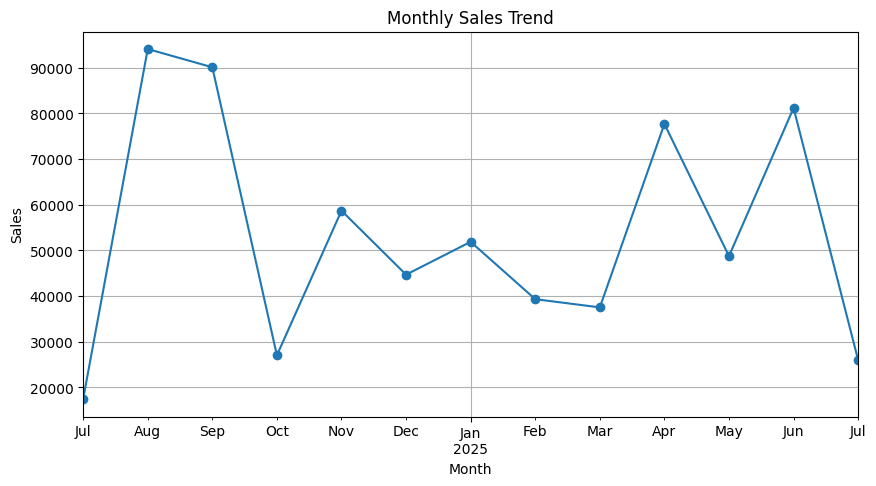

In [49]:
# 1. SALES TREND ANALYSIS OVER TIME.

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

print("Monthly Sales Trend")
print(monthly_sales)

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

Top Selling Products
Product Name
Curtains      79023.10
Comics        61394.03
Smartphone    58226.56
T-Shirt       46895.37
Smartwatch    42657.05
Lamp          41530.60
Perfume       37875.85
Lego Set      36345.05
Fiction       35729.68
Jeans         32370.84
Name: Sales, dtype: float64


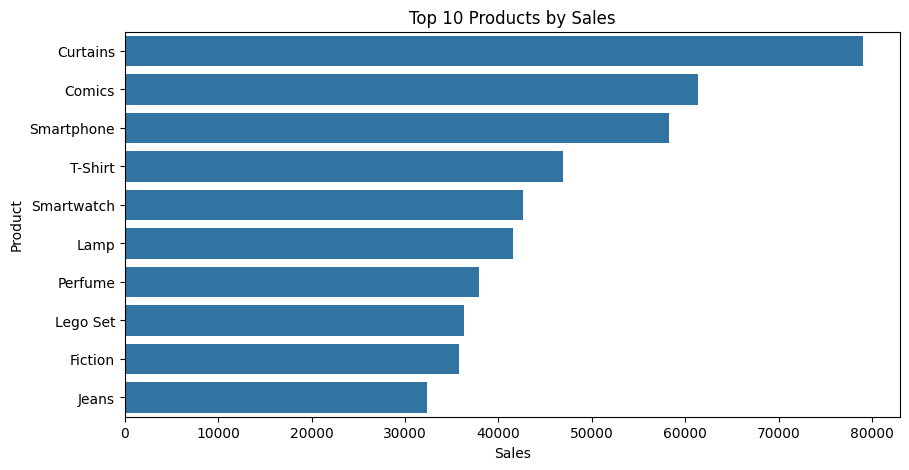

In [88]:
# 2. TOP-SELLING PRODUCTS

top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("Top Selling Products")
print(top_products)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_products.values,
    y=top_products.index,
)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()


Category Sales:
Product Category
Electronics    140811.26
Home           136365.47
Books          129177.30
Clothing       121504.99
Beauty          84457.92
Toys            81902.93
Name: Sales, dtype: float64


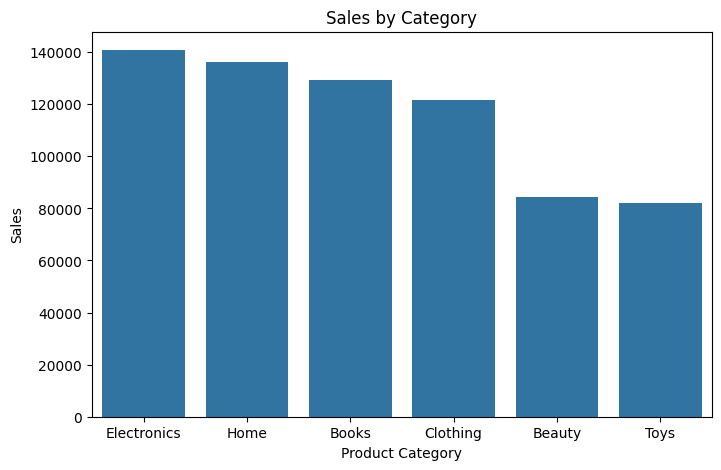

In [83]:
# Top category:

category_sales = (
    df.groupby('Product Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print("Category Sales:")
print(category_sales)

plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.bar_label
plt.show()

Sales by Age Group: 
Age_Group
18-25    114837.24
26-35    159482.88
36-45    140928.16
46-55    209270.39
55+       57615.47
Name: Sales, dtype: float64


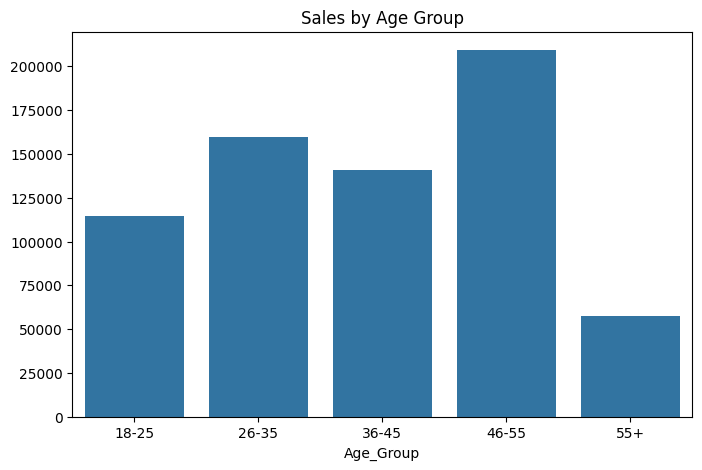

In [66]:
# 4. CUSTOMER SEGMENTATION BY AGE

age_bins = [18,25,35,45,55,100]
age_labels = ['18-25','26-35','36-45','46-55','55+']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels
)

age_sales = (
    df.groupby('Age_Group')['Sales'].sum())

print("Sales by Age Group: ")
print(age_sales)

plt.figure(figsize=(8,5))
sns.barplot(
    x=age_sales.index,
    y=age_sales.values
)
plt.title("Sales by Age Group")
plt.show()

Sales by Gender
Gender
Female    350229.35
Male      343990.52
Name: Sales, dtype: float64


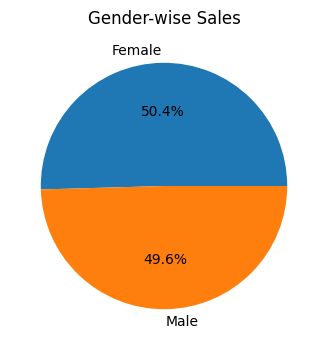

In [69]:
# 5. CUSTOMER SEGMENTATION BY GENDER
gender_sales = (
    df.groupby('Gender')['Sales'].sum())

print("Sales by Gender")
print(gender_sales)

plt.figure(figsize=(6,4))
gender_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.title("Gender-wise Sales")
plt.show()

City-wise Sales
City
Kolkata      190462.98
Hyderabad    130424.17
Mumbai       118183.95
Chennai      109181.81
Bangalore     90184.49
Delhi         55782.47
Name: Sales, dtype: float64


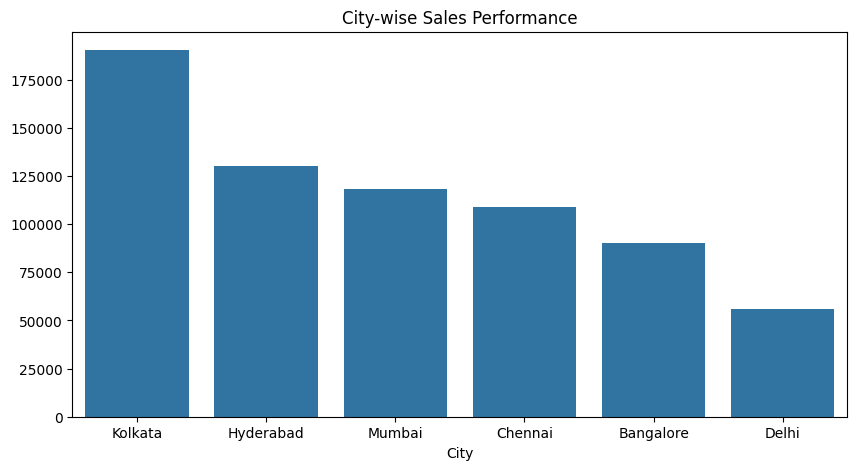

In [81]:
# 6. CITY-WISE SALES PERFORMANCE
city_sales = (
    df.groupby('City')['Sales']
    .sum()
    .sort_values(ascending=False)
)
print("City-wise Sales")
print(city_sales)

plt.figure(figsize=(10,5))
sns.barplot(
    x=city_sales.index,
    y=city_sales.values
)
plt.title("City-wise Sales Performance")
plt.bar_label
plt.show()


Payment Method Sales
Payment Method
Credit Card         205724.70
Netbanking          190707.30
Cash on Delivery    178313.61
UPI                 119474.26
Name: Sales, dtype: float64


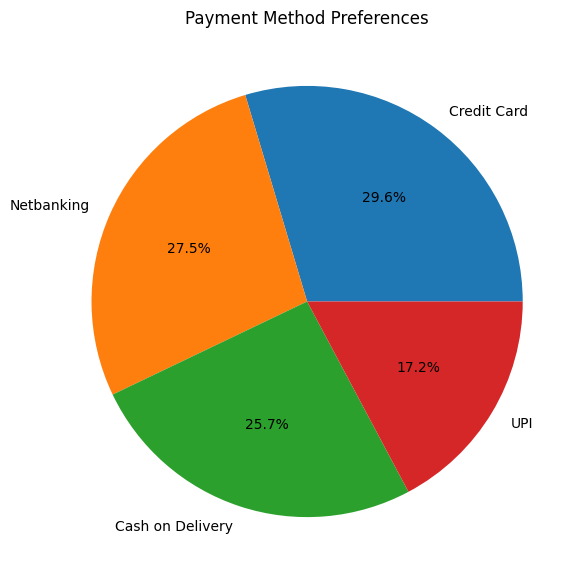

In [92]:
# 7. PAYMENT METHOD PREFERENCES

payment_sales = (
    df.groupby('Payment Method')['Sales']
    .sum()
    .sort_values(ascending=False)
)
print("Payment Method Sales")
print(payment_sales)

plt.figure(figsize=(7,7))
payment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.title("Payment Method Preferences")
plt.show()

In [94]:
# 8. KPI SUMMARY

total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

print("========== KPI SUMMARY ==========")
print(f"Total Sales      : {total_sales:,.2f}")
print(f"Total Orders     : {total_orders}")
print(f"Total Customers  : {total_customers}")
print("=================================")

========== KPI SUMMARY ==========
Total Sales      : 694,219.87
Total Orders     : 100
Total Customers  : 98
